# Model 2 — ResNet18 (CNN, ImageNet Fine-Tuning)

**Owner:** Advait Gujar (230911404)

> **Depends on:** run `00_shared_pipeline.ipynb` first, in the same kernel (it builds `train_df`/`val_df`/`test_df`, the DataLoaders, `pos_weights`, `criterion`, and the shared `train_model`/`evaluate` functions used below).

## Architecture & Train

An 18-layer residual network, pretrained on ImageNet-1K, fine-tuned end to end with a two-stage freeze schedule (backbone frozen for epochs 1–2, unfrozen from epoch 3).

In [1]:
class ResNet18Wrapper(nn.Module):
    """Thin wrapper so train_model's freeze_schedule logic (which looks for
    .backbone) works uniformly across models."""
    def __init__(self, num_classes=5, dropout=0.3):
        super().__init__()
        self.backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(in_features, num_classes))

    def forward(self, x):
        return self.classifier(self.backbone(x))

resnet_model = ResNet18Wrapper(num_classes=len(DISEASE_COLS))
resnet_model, resnet_history = train_model(resnet_model, 'resnet18', freeze_schedule=True)

[resnet18] Epochs 1-2: backbone frozen
[resnet18] Epoch 1/5  Train Loss: 1.0206  Train AUC: 0.6092  Val Loss: 0.9710  Val AUC: 0.6706
[resnet18] Epoch 2/5  Train Loss: 0.9939  Train AUC: 0.6438  Val Loss: 0.9684  Val AUC: 0.6777
[resnet18] Epoch 3+: full model unfrozen
[resnet18] Epoch 3/5  Train Loss: 0.8753  Train AUC: 0.7549  Val Loss: 0.8390  Val AUC: 0.7860
[resnet18] Epoch 4/5  Train Loss: 0.8293  Train AUC: 0.7836  Val Loss: 0.8056  Val AUC: 0.7972
[resnet18] Epoch 5/5  Train Loss: 0.8044  Train AUC: 0.7984  Val Loss: 0.7946  Val AUC: 0.8034


In [21]:
with open(os.path.join(OUTPUT_DIR, 'resnet18_history.json'), 'w') as f:
    json.dump(resnet_history, f)

## Evaluate on Test Set

In [3]:
_, resnet_test_auc, resnet_test_labels, resnet_test_preds = evaluate(resnet_model, test_loader, criterion)
print(f"ResNet18 Test Mean AUC: {resnet_test_auc:.4f}")

ResNet18 Test Mean AUC: 0.8043


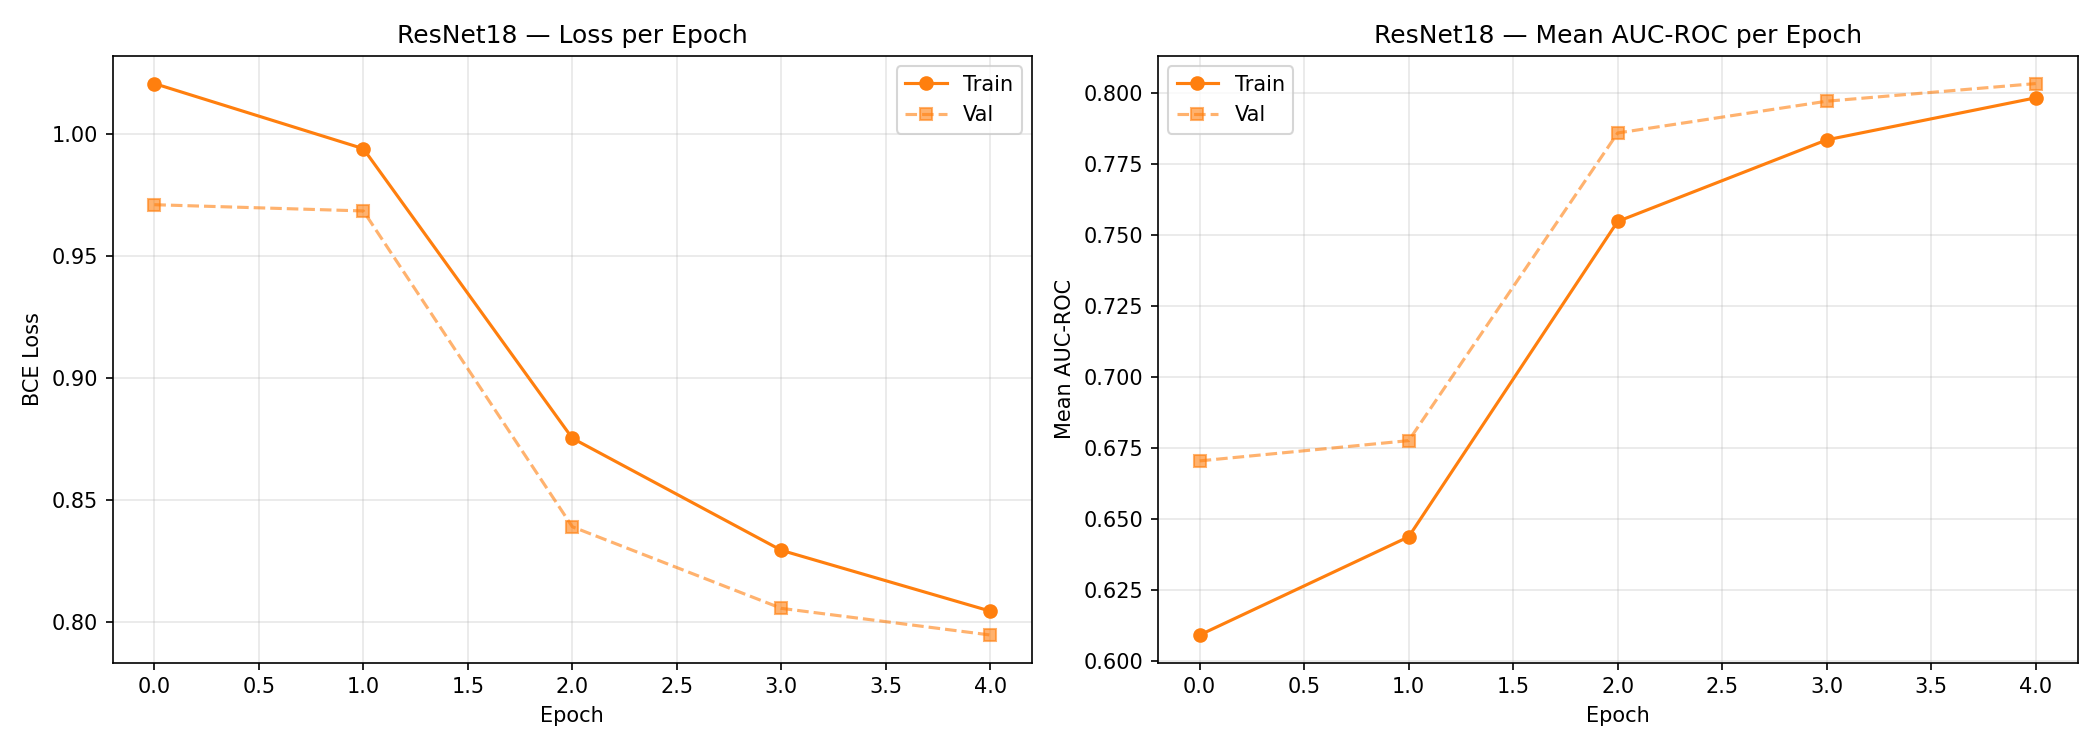

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(resnet_history['train_loss'], marker='o', label='Train', color='tab:orange')
axes[0].plot(resnet_history['val_loss'], marker='s', label='Val', color='tab:orange', alpha=0.6, linestyle='--')
axes[0].set_title('ResNet18 — Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(resnet_history['train_auc'], marker='o', label='Train', color='tab:orange')
axes[1].plot(resnet_history['val_auc'], marker='s', label='Val', color='tab:orange', alpha=0.6, linestyle='--')
axes[1].set_title('ResNet18 — Mean AUC-ROC per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean AUC-ROC')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'resnet18_loss_auc_curves.png'), dpi=150)
plt.show()

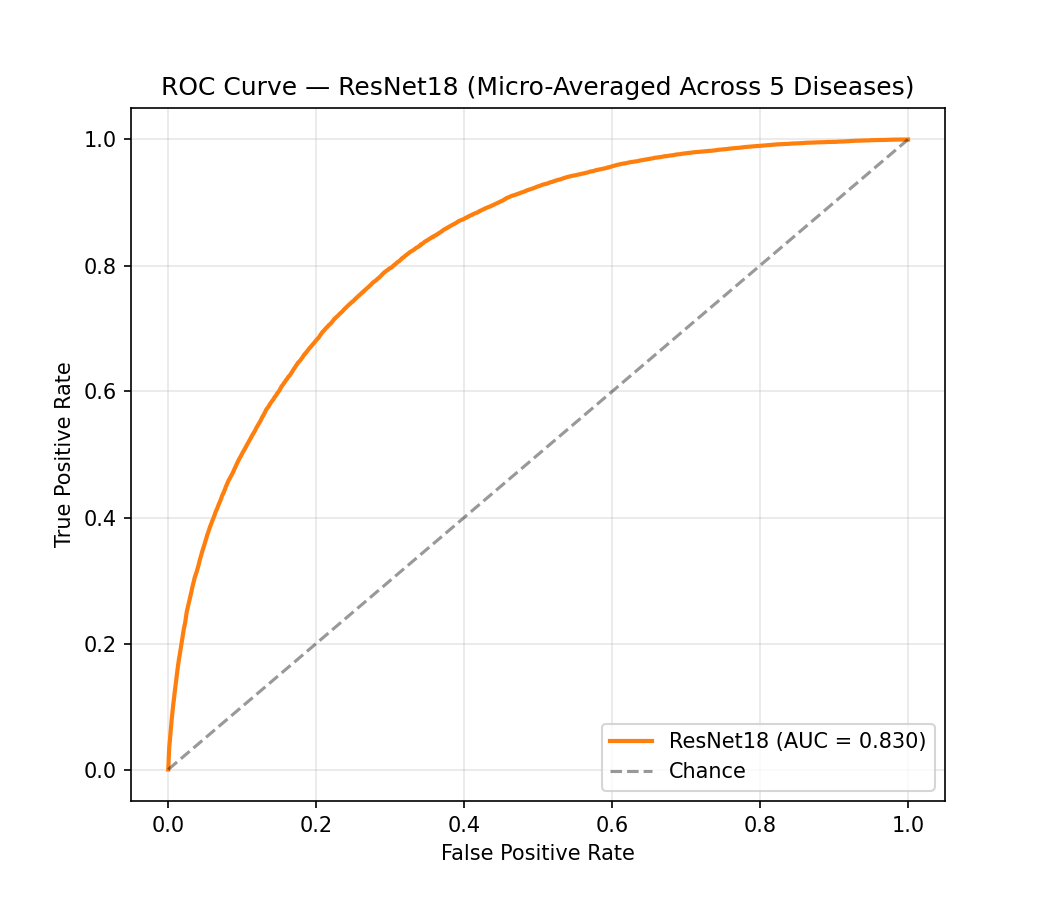

In [5]:
fpr, tpr, _ = roc_curve(resnet_test_labels.ravel(), resnet_test_preds.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'ResNet18 (AUC = {roc_auc:.3f})', color='tab:orange', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Chance')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — ResNet18 (Micro-Averaged Across 5 Diseases)')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'resnet18_roc.png'), dpi=150)
plt.show()

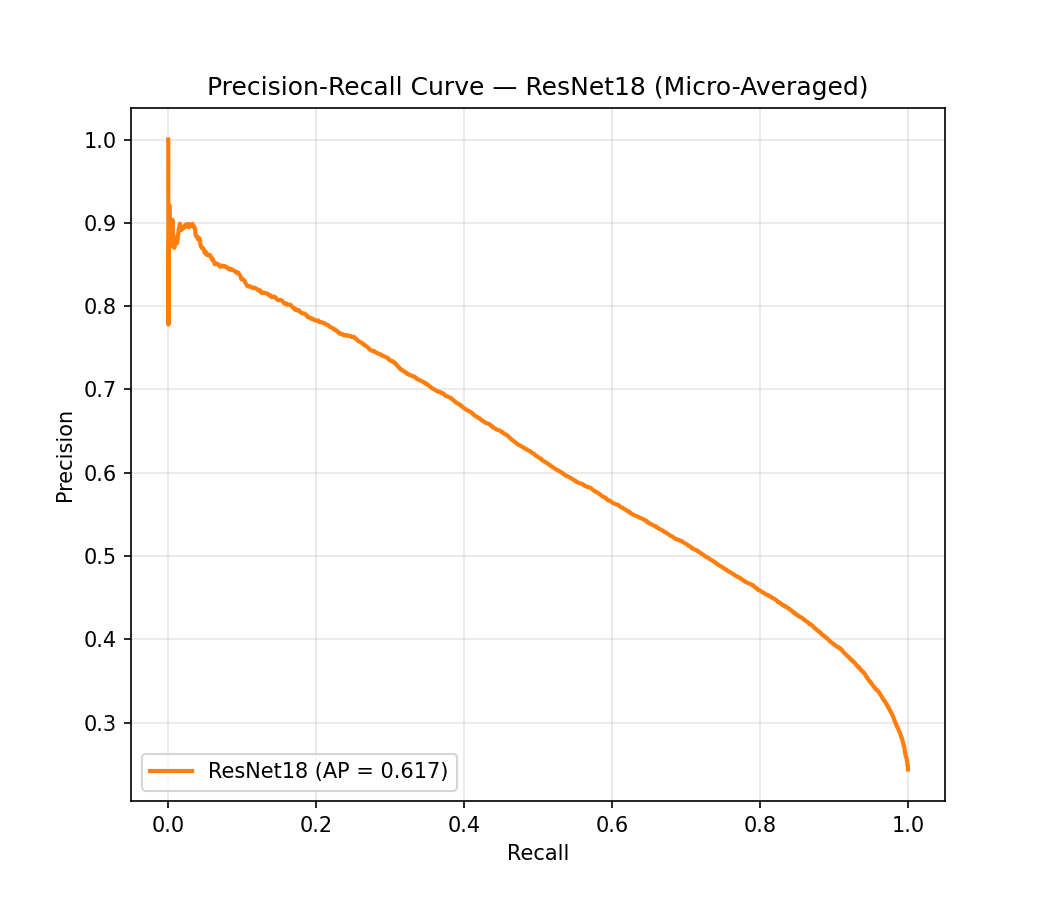

In [6]:
precision, recall, _ = precision_recall_curve(resnet_test_labels.ravel(), resnet_test_preds.ravel())
ap = average_precision_score(resnet_test_labels, resnet_test_preds, average='micro')

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f'ResNet18 (AP = {ap:.3f})', color='tab:orange', linewidth=2)
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve — ResNet18 (Micro-Averaged)')
plt.legend(loc='lower left'); plt.grid(alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'resnet18_pr.png'), dpi=150)
plt.show()

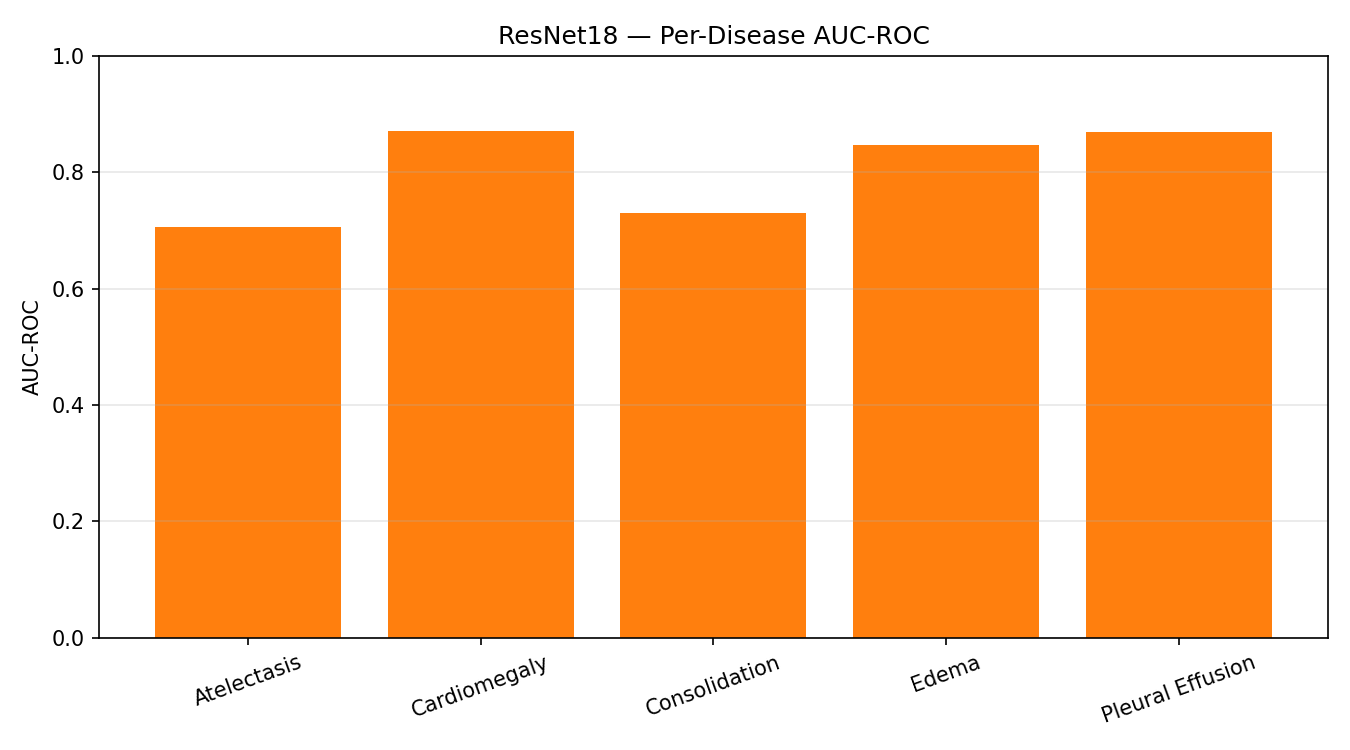

In [7]:
resnet_per_disease = _per_disease_auc(resnet_test_labels, resnet_test_preds)

plt.figure(figsize=(9, 5))
plt.bar(DISEASE_COLS, resnet_per_disease, color='tab:orange')
plt.ylabel('AUC-ROC'); plt.ylim(0, 1.0)
plt.title('ResNet18 — Per-Disease AUC-ROC')
plt.xticks(rotation=20)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'resnet18_per_disease_auc.png'), dpi=150)
plt.show()

for d, a in zip(DISEASE_COLS, resnet_per_disease):
    print(f"{d:20s}: {a:.4f}")

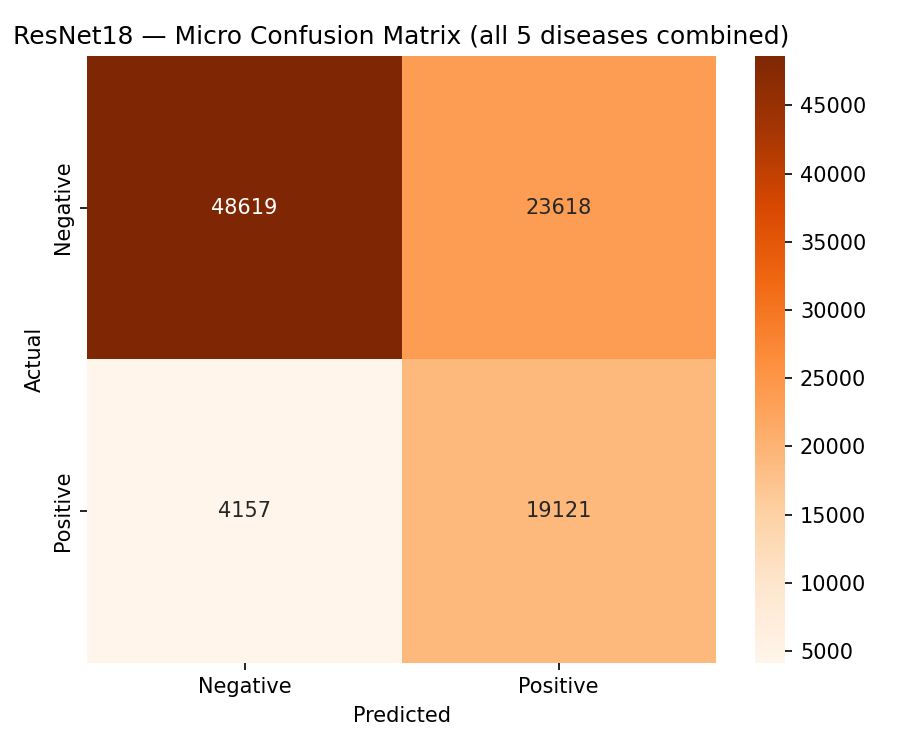

In [8]:
resnet_binary_preds = (resnet_test_preds >= 0.5).astype(int)
resnet_cm = confusion_matrix(resnet_test_labels.ravel(), resnet_binary_preds.ravel())

plt.figure(figsize=(6, 5))
sns.heatmap(resnet_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('ResNet18 — Micro Confusion Matrix (all 5 diseases combined)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'resnet18_confusion_matrix.png'), dpi=150)
plt.show()